# Volume 2: Non-negative Matrix Factorization
    <Name>
    <Class>
    <Date>

In [70]:
import numpy as np
import cvxpy as cp
from matplotlib import pyplot as plt
import os
import zipfile
from imageio.v3 import imread
import warnings
warnings.filterwarnings("ignore")
from sklearn.decomposition import NMF

## Problems 1-2

In [71]:
class NMFRecommender:

    def __init__(self, random_state=15, rank=3, maxiter=200, tol=1e-3):
        """The parameter values for the algorithm"""
        # The usual
        self.random_state = random_state
        self.rank = rank
        self.maxiter = maxiter
        self.tol = tol
        
    
    def initialize_matrices(self, m, n):
        """randomly initialize the W and H matrices,"""
        self.m = m
        self.n = n
        np.random.seed(self.random_state) # I don't understand this syntax
        self.W = np.random.random((m, self.rank))
        self.H = np.random.random((self.rank, n))

      
    def fit(self, V):
        """Fits W and H weight matrices using CVXPY"""
        def loop_is_not_over(old_W, new_W, old_H, new_H, counter):
            return np.linalg.norm(old_W - new_W, 'fro') >= self.tol and np.linalg.norm(old_H - new_H, 'fro') >= self.tol and counter < self.maxiter # We'll use this to stop the while loop
        
        # I think we'll do the first step here
        old_H = self.H.copy()
        old_W = self.W.copy()

        # First W solve
        x = cp.Variable(self.W.shape, nonneg=True) # Pretty much just a dummy for W
        objective = cp.Minimize(cp.norm(V - (x @ old_H), 'fro'))
        problem = cp.Problem(objective)
        problem.solve()
        new_W = x.value # Very nice

        # First H solve
        x = cp.Variable(self.H.shape, nonneg=True) # Another dummy variable for H
        objective = cp.Minimize(cp.norm(V - (new_W @ x), 'fro'))
        problem = cp.Problem(objective)
        problem.solve()
        new_H = x.value # Very nice
        counter = 1


        while loop_is_not_over(old_W, new_W, old_H, new_H, counter):
            # Solve for W
            x = cp.Variable(self.W.shape, nonneg=True) # Pretty much just a dummy for W
            objective = cp.Minimize(cp.norm(V - (x @ old_H), 'fro'))
            problem = cp.Problem(objective)
            problem.solve()
            old_W, new_W = new_W, x.value

            if not loop_is_not_over(old_W, new_W, old_H, new_H, counter): # Have to check between solving W and solving H (maybe)
                break

            # Solve for H
            x = cp.Variable(self.H.shape, nonneg=True) # Another dummy variable for H
            objective = cp.Minimize(cp.norm(V - (new_W @ x), 'fro'))
            problem = cp.Problem(objective)
            problem.solve()
            old_H, new_H = new_H, x.value # Very nice
        
        self.H = new_H
        self.W = new_W


    def reconstruct(self):
        """Reconstruct V matrix for comparison against the original V"""
        return self.W @ self.H # I don't feel like this warrents a comment
    
    
idk = NMFRecommender()
V = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
idk.initialize_matrices(3, 4)
idk.fit(V)
print(idk.W)
print(idk.H)
print(idk.reconstruct())

[[1.61213695 0.74077694 3.0689591 ]
 [2.07169387 5.31756221 6.40819866]
 [2.53074908 9.89423501 9.74758067]]
[[5.61978365e-06 3.52264542e-02 1.76458835e-01 3.18532487e-01]
 [7.72252028e-01 4.95778144e-01 2.55711568e-01 1.59339110e-02]
 [1.39432706e-01 5.13512567e-01 8.23112615e-01 1.13220097e+00]]
[[ 0.99998883  1.99999995  2.99999999  3.99999994]
 [ 5.00002233  6.00000009  7.00000001  8.00000011]
 [ 8.99998883  9.99999995 10.99999999 11.99999995]]


## Problem 3

In [72]:
def prob3():
    """Run NMF recommender on the grocery store example"""
    V = np.array(
        [
            [0, 1, 0, 1, 2, 2],
            [2, 3, 1, 1, 2, 2],
            [1, 1, 1, 0, 1, 1],
            [0, 2, 3, 4, 1, 1],
            [0, 0, 0, 0, 1, 0]
        ]
    )

    idk = NMFRecommender() # My favorite variable
    idk.initialize_matrices(5, 6)
    idk.fit(V)
    component_1 = idk.H[0] # I don't know a better way to do this
    component_2 = idk.H[1]
    total = np.sum((component_1 - component_2) < 0) # Very nice
    return idk.W, idk.H, total

In [73]:
# Implement prob 3 here
prob3()

(array([[1.77836085e+00, 1.14291966e+00, 1.06130399e-07],
        [1.87255303e+00, 2.41935089e+00, 1.39356878e-07],
        [4.68950370e-01, 6.63552792e-01, 7.93520953e-01],
        [4.84539286e-08, 2.18177565e+00, 1.13372495e+00],
        [4.60765802e-07, 4.48708621e-01, 6.28006594e-07]]),
 array([[3.84690462e-01, 2.02994910e-01, 0.00000000e+00, 0.00000000e+00,
         8.27610420e-01, 1.02910620e+00],
        [2.27513015e-01, 9.35677101e-01, 3.88833494e-01, 6.59548115e-01,
         2.78929030e-01, 6.06010985e-02],
        [4.61137370e-09, 9.31130091e-02, 1.58128212e+00, 1.33482778e+00,
         4.08593503e-01, 7.11472743e-01]]),
 np.int64(3))

## Problem 4

In [74]:
def get_faces(path="./faces94.zip"):
    '''
    Traverse the specified directory (or zip file) to obtain one image from each subfolder,
    convert each image to grayscale, flatten it, and stack them as columns
    of a data matrix.

    Parameters
    ----------
    path : str
        Directory path (or zip archive) containing the faces94 dataset.

    Returns
    -------
    V : ndarray
        Each column of V is a vectorized face image (flattened to 1D).
    '''
    faces = []        # List to store flattened face images.
    subs = set()      # Track which subfolders have been sampled.

    # Open the zip file containing the dataset.
    with zipfile.ZipFile(path, 'r') as z:
        for info in z.infolist():
            # Skip directories (only process files).
            if info.is_dir():
                continue

            # Only take the *first* image from each subdirectory.
            dn = os.path.dirname(info.filename)
            if dn in subs:
                continue

            # Only process jpg images.
            if not info.filename.lower().endswith("jpg"):
                continue

            subs.add(dn)

            # Read the image from the archive, convert to grayscale, flatten.
            face = imread(z.read(info.filename)).mean(axis=2).ravel()
            faces.append(face)
    
    # Stack face vectors as columns in matrix V.
    return np.transpose(faces)

def show(image, m=200, n=180):
    """Plot the flattened grayscale 'image' of width 'w' and height 'h'.

    Parameters
    ----------
    image : ((mn,) ndarray)
        A flattened image.
    filename: str
        .png filename for saving your figure
    m : int
        The original number of rows in the image.
    n : int
        The original number of columns in the image.

    Returns
    -------
    None
    """
    # Scale image
    image = image / 255
    # Reshape image
    image = np.reshape(image, (m, n))
    # Show image
    plt.imshow(image, cmap="gray")

    # Save the figure
    # plt.savefig(filename)

In [75]:
def prob4():
    """Gridsearch over rank, alpha and l1_ratio values to reconstruct 
    image using NMF. Plot all reconstructed images. Determine which set 
    of paramenters best reconstructs the face
    """
    j = 0
    norms = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: []}
    V = get_faces()
    for n in [75]:
        for alpha_W in [0, 0.2, 0.5]:
            for l1_ratio in [0, 1e-5, 1]:
                model = NMF(n_components=n, init='random', random_state=0, alpha_W=alpha_W, l1_ratio=l1_ratio) # Gotta run through all combinations
                W = model.fit_transform(V)
                H = model.components_
                norms[j].append(np.linalg.norm(V - W @ H, "fro"))
                j = (j + 1) % 9
    return norms


In [ ]:
# Implement prob 4 here
dict = prob4()
print(np.mean(dict[0]))
print(np.mean(dict[1]))
print(np.mean(dict[2]))
print(np.mean(dict[3]))
print(np.mean(dict[4]))
print(np.mean(dict[5]))
print(np.mean(dict[6]))
print(np.mean(dict[7]))
print(np.mean(dict[8]))

The parameters that reconstruct the face the best are: 75, 0.5, 1

## Problem 5

In [ ]:
def prob5():
    """Find the 10 basis faces with the largest coefficients corresponding 
    to the the 2nd and 12th faces in the dataset. Plot these basis faces 
    along with the original image using subplots
    """
    V = get_faces()
    model = NMF(n_components=75, init='random', random_state=0, alpha_W=0.5, l1_ratio=1)
    W = model.fit_transform(V)
    H = model.components_
    return W, H

In [ ]:
# Implement prob 5 here
W, H = prob5()

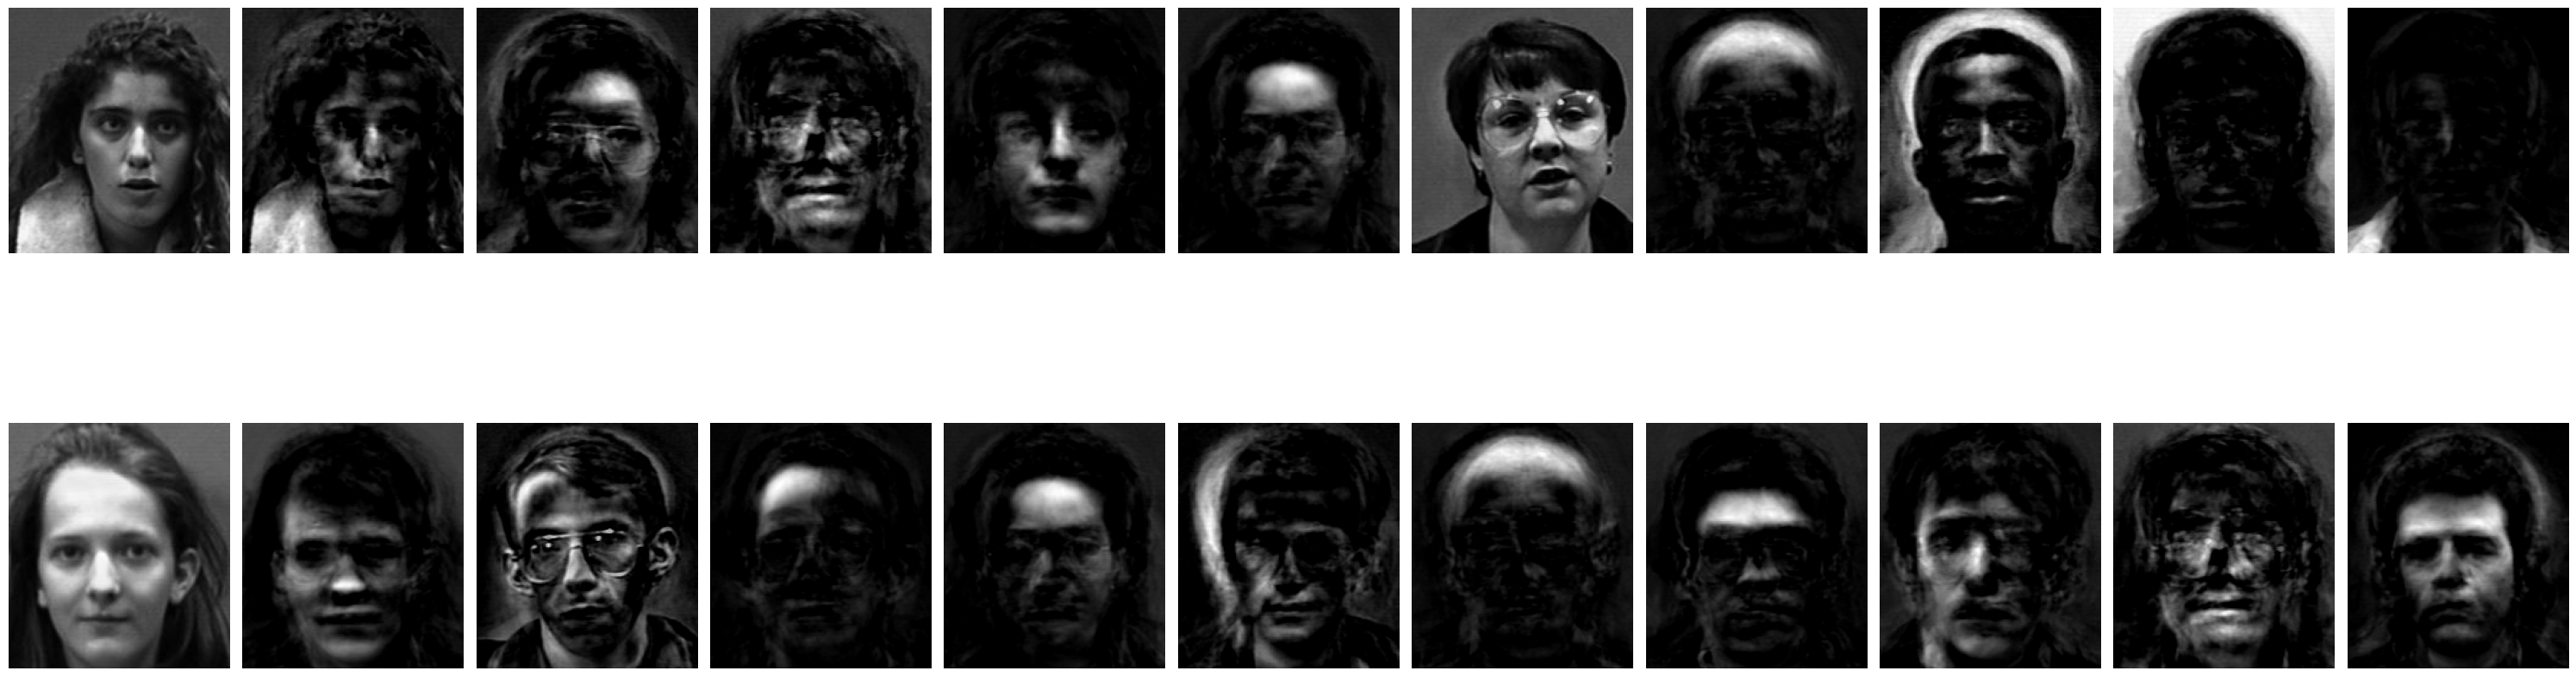

In [ ]:
second_face = np.argsort(H[:, 1])[::-1][:10]
twelfth_face = np.argsort(H[:, 11])[::-1][:10]

V = get_faces()
plt.figure(figsize=(30, 12))
plt.subplot(2, 11, 1)
show(V[:, 1], 200, 180)
plt.axis("off")
plt.subplot(2, 11, 12)
show(V[:, 11], 200, 180)
plt.axis("off")
for i in range(10):
    plt.subplot(2, 11, i + 2)
    plt.axis("off")
    show(W[:, second_face[i]], 200, 180)
    plt.subplot(2, 11, i + 13)
    show(W[:, twelfth_face[i]], 200, 180)
    plt.axis("off")
plt.tight_layout()
plt.show()

Write a sentence or two about the differences you notice in the features of the basis faces:

They seem to capture more distinct facial features such as eyes, nose, and mouth separately, rather than blending them together. This allows for a more interpretable representation of the faces, where each basis face corresponds to a specific facial component.